In [ ]:
import lerobot
# from lerobot.datasets.lerobot_dataset import LeRobotDataset, LeRobotDatasetMetadata
from lerobot.common.datasets.lerobot_dataset import LeRobotDataset
import numpy as np
from openpi_client import image_tools
from openpi_client import websocket_client_policy as _websocket_client_policy

In [2]:
repo_id = "/home/ns/lerobot_data/franka_2_libero_like"

In [3]:
dataset = LeRobotDataset(repo_id)
print(f"Number of episodes selected: {dataset.num_episodes}")
print(f"Number of frames selected: {dataset.num_frames}")

Resolving data files:   0%|          | 0/70 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

Number of episodes selected: 70
Number of frames selected: 15490


In [4]:
episode = dataset[0]

print(episode.keys())


dict_keys(['image', 'wrist_image', 'state', 'actions', 'timestamp', 'frame_index', 'episode_index', 'index', 'task_index', 'task'])


In [5]:
 
# Example fields (dataset-dependent)
rgb = episode["image"]          # (T, H, W, 3)
state = episode["state"]        # (T, D)

actions = episode["actions"] # (T, A)

print(rgb.shape, state.shape, actions.shape)


torch.Size([3, 256, 256]) torch.Size([8]) torch.Size([7])


In [6]:
dir(dataset)
dataset.episodes 

In [7]:
episode_index = 0

# What columns exist?
print("episode columns:", list(dataset.meta.episodes.keys())) 
 


episode columns: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69]


In [8]:
ep0 = dataset.meta.episodes[0]
print("type:", type(ep0))

# If it's dict-like
if hasattr(ep0, "keys"):
    print("episode fields:", list(ep0.keys()))
    for k in ep0.keys():
        print(k, "=", ep0[k])

type: <class 'dict'>
episode fields: ['episode_index', 'tasks', 'length']
episode_index = 0
tasks = ['pick up the coffee pod']
length = 189


In [9]:
ep = dataset[0]
print(type(ep))
print(ep.keys())


<class 'dict'>
dict_keys(['image', 'wrist_image', 'state', 'actions', 'timestamp', 'frame_index', 'episode_index', 'index', 'task_index', 'task'])


In [10]:
ep = dataset[0]
img_keys = [k for k in ep.keys() if any(s in k.lower() for s in ["image", "rgb", "cam", "camera", "pixels"])]
print("image-ish keys:", img_keys)


image-ish keys: ['image', 'wrist_image']


In [11]:
ep = dataset[0]
camera_key = img_keys[0]   # pick one that exists
frames = ep[camera_key]    # usually a torch.Tensor of shape (T, H, W, C) or (T, C, H, W)

print(type(frames))
print(frames.shape)


<class 'torch.Tensor'>
torch.Size([3, 256, 256])


In [12]:
print("len(dataset) =", len(dataset))
print("episode0 length =", dataset.meta.episodes[0]["length"])


len(dataset) = 15490
episode0 length = 189


In [ ]:


episode_index = 1

lengths = np.array([ep["length"] for ep in dataset.meta.episodes.values()], dtype=np.int64)

starts = np.zeros_like(lengths)
starts[1:] = np.cumsum(lengths[:-1])

from_idx = int(starts[episode_index])
to_idx   = int(starts[episode_index] + lengths[episode_index])

print("from_idx,to_idx:", from_idx, to_idx, "len:", to_idx - from_idx)


from_idx,to_idx: 189 438 len: 249


In [14]:
sample = dataset[from_idx]
print("sample keys (first 60):", list(sample.keys())[:60])
 
img_keys = ['image', 'wrist_image'] 

camera_key = img_keys[0]  # pick one
frames = [dataset[i][camera_key] for i in range(from_idx, to_idx)]

print(type(frames[0]))
print(getattr(frames[0], "shape", None))


sample keys (first 60): ['image', 'wrist_image', 'state', 'actions', 'timestamp', 'frame_index', 'episode_index', 'index', 'task_index', 'task']
<class 'torch.Tensor'>
torch.Size([3, 256, 256])


In [15]:
samples = [dataset[i] for i in range(from_idx, to_idx)]
len(samples)

249

In [16]:
actions_original = [samples[i]['actions'] for i in range(len(samples))]
actions_original = np.array(actions_original)
actions_original.shape

(249, 7)

In [17]:
len(frames)

249

In [18]:
#convert 3x224x224 to 224x224x3
frame = frames[0].permute(1,2,0).numpy()
frame.shape

(256, 256, 3)

In [19]:
sample.keys()

dict_keys(['image', 'wrist_image', 'state', 'actions', 'timestamp', 'frame_index', 'episode_index', 'index', 'task_index', 'task'])

In [20]:
obs={
        "observation/state": sample['state'][:].numpy(),
        "observation/image": sample['image'][:].permute(1,2,0).numpy(),
        "observation/wrist_image": sample['wrist_image'][:].permute(1,2,0).numpy(),
        "prompt": sample['task'],
    }

In [21]:
for key in obs.keys():
  if 'prompt' in key or 'text' in key:
    print('key', key, 'data=', obs[key])
    continue
  print(f"{key}: {obs[key].shape} {obs[key].dtype}")

observation/state: (8,) float32
observation/image: (256, 256, 3) float32
observation/wrist_image: (256, 256, 3) float32
key prompt data= pick up the coffee pod


In [23]:
import dataclasses

@dataclasses.dataclass
class Args:
    #################################################################################################################
    # Model server parameters
    #################################################################################################################
    host: str = "0.0.0.0"
    port: int = 8000
    resize_size: int = 224
    replan_steps: int = 5

    #################################################################################################################
    # LIBERO environment-specific parameters
    #################################################################################################################
    task_suite_name: str = (
        "libero_90"  # Task suite. Options: libero_spatial, libero_object, libero_goal, libero_10, libero_90
    )
    num_steps_wait: int = 10  # Number of steps to wait for objects to stabilize i n sim
    num_trials_per_task: int = 5   # Number of rollouts per task

    #################################################################################################################
    # Utils
    #################################################################################################################
    video_out_path: str = "data/libero/videos"  # Path to save videos

    seed: int = 7  # Random Seed (for reproducibility)


In [24]:
args= Args()

In [25]:
client = _websocket_client_policy.WebsocketClientPolicy(args.host, args.port)


In [26]:
action_chunk = client.infer(obs)["actions"]
action_chunk.shape

(10, 7)

In [27]:
import collections
action_plan = collections.deque()
t = 0
replay_images = []

In [28]:
acs=[]
while t < len(actions_original):
    try: 
        sample = samples[t] 
        if not action_plan:
            # Finished executing previous action chunk -- compute new chunk
            # Prepare observations dict
            element={
                "observation/state": sample['state'][:].numpy(),
                "observation/image": sample['image'][:].permute(1,2,0).numpy(),
                "observation/wrist_image": sample['wrist_image'][:].permute(1,2,0).numpy(),
                "prompt": sample['task'],
            } 

            # Query model to get action
            action_chunk = client.infer(element)["actions"]
            assert (
                len(action_chunk) >= args.replan_steps
            ), f"We want to replan every {args.replan_steps} steps, but policy only predicts {len(action_chunk)} steps."
            action_plan.extend(action_chunk[: args.replan_steps])

        action = action_plan.popleft()

        acs.append(action)
        t += 1

    except Exception as e: 
        break

In [30]:
acs = np.array(acs)
acs.shape

(249, 7)

In [31]:
action_original=actions_original
# action_prediction=np.array(action_prediction) 
action_prediction = acs 
action_original.shape, action_prediction.shape

((249, 7), (249, 7))

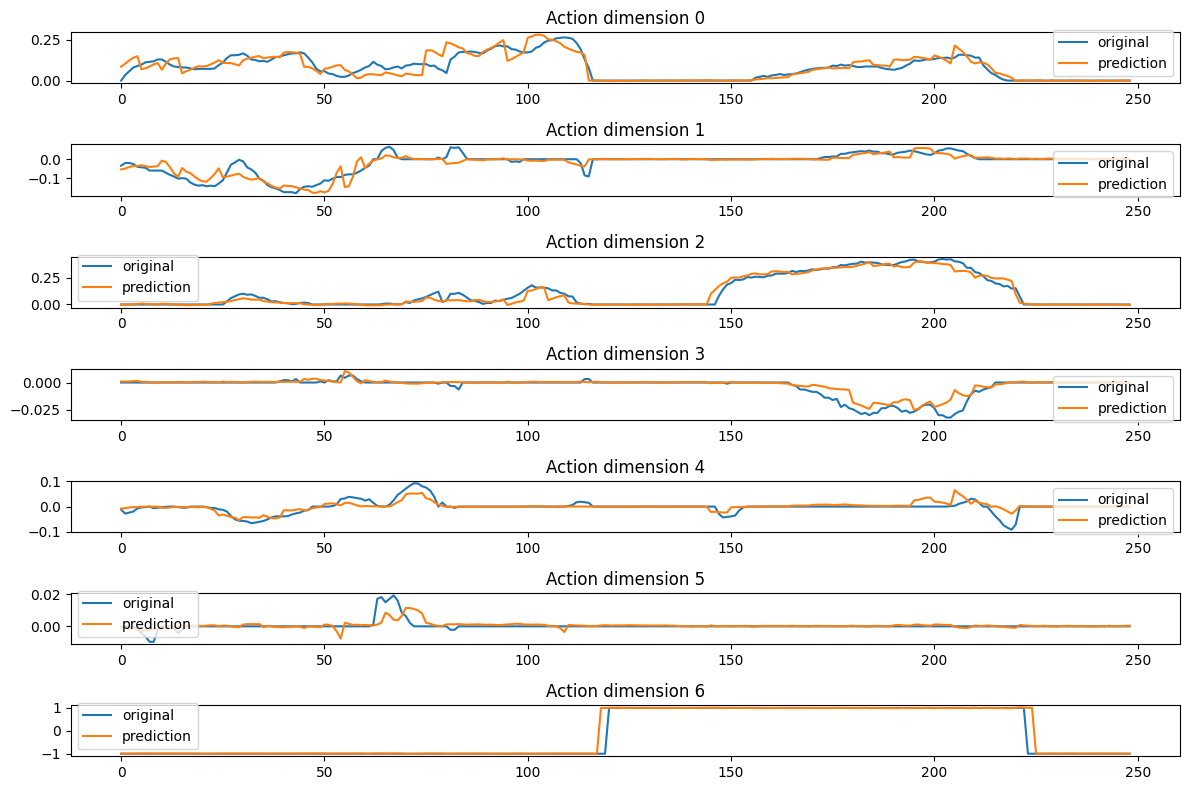

In [32]:
#plot comparison
import matplotlib.pyplot as plt
plt.figure(figsize=(12,8))
for i in range(action_original.shape[1]):
    plt.subplot(action_original.shape[1],1,i+1)
    plt.plot(action_original[:,i], label='original')
    plt.plot(action_prediction[:, i], label='prediction')
    plt.title(f'Action dimension {i}')
    plt.legend()
plt.tight_layout()
plt.show()